# Pillar 5: Capstone Project
**HW by: Lorenzo Carlos Baquiran (LCB) | AI/ML Batch 2025-2026**

---

**Learning Outcome Addressed**
- Develop a robust foundational understanding of artificial intelligence (AI) and machine learning (ML) concepts and technologies
- Equip learners with the knowledge and skills to identify and implement AI solutions across various sectors effectively.
- Develop proficiency in AI/ML tools and frameworks.
- Develop a holistic understanding of AI concepts and techniques, enabling them to effectively address complex real-world problems by designing, implementing and evaluating AI and ML models.
- Develop hands-on skills in modelling, training and deploying these models in real-world applications.


To demonstrate the end-to-end application of the machine learning lifecycle—including problem framing, data preprocessing, modelling, evaluation and result communication—on a real-world, industry-relevant dataset of choice.

#### LCB Chosen Project Domain = **Healthcare: Predict disease likelihood** = STROKE

---


# Step 1️⃣: Problem Understanding & Framing 
- Frame the business and data science problem clearly.
- Define whether it's a classification, regression, recommendation, anomaly detection, or clustering task.
- Specify success metrics (e.g., Accuracy, AUC, RMSE, Silhouette Score) and business KPIs (e.g., cost savings, uplift).

**Capstone linkage: Module 1 output maps to Capstone Steps 1–3.**

**Deliverable: Clear problem statement + task type + target metric.**


## 1.1 Problem Statement

Stroke is one of the leading causes of death and long-term disability worldwide. It occurs when blood flow to the brain is disrupted, leading to brain damage and potentially life-threatening complications. Early identification of individuals at high risk of stroke is important because many risk factors, such as hypertension, lifestyle habits and underlying health conditions, can be managed or controlled through timely intervention.

Globally, stroke continues to contribute significantly to the burden of non-communicable (or non-infectious) diseases, particularly in low- and middle-income countries where access to preventive healthcare may be limited. 

🇵🇭 In the Philippines, stroke is consistently reported as one of the leading causes of mortality based on national health statistics. Risk factors such as hypertension, diabetes, smoking and sedentary lifestyles are common, making stroke prevention a major public health priority.

This project aims to develop a machine learning model that predicts whether an individual is likely to experience a stroke based on demographic, lifestyle and clinical factors. These include variables such as age, hypertension status, heart disease, body mass index (BMI), smoking status and average glucose level.

By identifying patterns across these variables, the model can help estimate stroke risk and support early detection strategies. Such predictive tools may assist healthcare providers and public health programs in prioritising high-risk individuals for screening, monitoring and preventive interventions.

---

## 1.2 Data Task Type

This problem is framed as a **SUPERVISED learning classification task**.

The objective is to classify whether a patient is likely to experience a stroke based on their health and demographic characteristics.

**Target Variable**

`stroke`

Values:

- **1 → Patient has experienced a stroke**
- **0 → Patient has not experienced a stroke**

---

## 1.3 Success Metrics (Model Evaluation)

The performance of the model will be evaluated using several classification metrics.

| Metric | Description |
|---|---|
| **Accuracy** | Measures the proportion of correctly predicted cases. |
| **Precision** | Measures how many patients predicted to have a stroke actually had a stroke. |
| **Recall (Sensitivity)** | Measures how many actual stroke cases were correctly identified. |
| **F1 Score** | Balances precision and recall for overall model performance. |
| **AUC (Area Under the ROC Curve)** | Measures the model’s ability to distinguish between stroke and non-stroke cases. |

In this problem, **recall is especially important**, because failing to identify individuals at risk of stroke could delay preventive interventions and increase the likelihood of severe outcomes.

---

### Business / Healthcare Impact (KPIs)

From a healthcare and public health perspective, predictive models for stroke risk can support:

- **Early identification of high-risk individuals**
- **Improved preventive healthcare strategies**
- **Reduced stroke incidence through timely intervention**
- **Better allocation of healthcare resources for screening programs**

In the Philippine context, such models may be particularly useful in supporting community-level screening and preventive care, especially in areas with limited access to specialised healthcare services.

---

### Project Scope

This project will follow the complete machine learning lifecycle:

1. Data collection and understanding  
2. Data preprocessing and exploratory data analysis (EDA)  
3. Feature engineering and dimensionality reduction  
4. Model training and evaluation using multiple algorithms  
5. Model interpretation and fairness considerations  

The final output will be a machine learning model capable of predicting stroke risk based on patient characteristics and health indicators.

---

# Step 2️⃣: Data Collection & Understanding
- Use public datasets (Kaggle, UCI, APIs, etc.) or approved custom data.
- Summarise feature types, missing values, outliers, etc.
- Provide a data dictionary (variables, types, units, allowed values).

**Deliverable: Dataset overview + data dictionary.**

## 2.1 Dataset Overview

This project uses the **Stroke Prediction dataset**, which contains patient-level data related to demographic, lifestyle and clinical factors associated with stroke risk.

Each row in the dataset represents an individual patient, and each column represents a feature such as age, health conditions or lifestyle habits. The dataset is used to predict whether a patient has experienced a stroke.

The features include a mix of numerical and categorical variables such as age, hypertension, heart disease, body mass index (BMI), smoking status and average glucose level.

// In layman's terms we can think of this dataset as a table where each row is a person and each column describes something about them (like age, whether they smoke, or if they have hypertension). The last column tells us whether they had a stroke or not. The goal is to use the other columns to predict that outcome.

In [163]:
# Import required libraries

# For Data manipulation
import pandas as pd
import numpy as np

# For Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [164]:
# Load dataset
df = pd.read_csv("healthcare_dataset_stroke_data.csv")

# Preview the first few rows
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [165]:
# Check dataset dimensions / shape
df.shape

(5110, 12)

In [166]:
# View dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


**Dataset Structure Observation:**
The dataset contains both numerical and categorical variables. Features like age, BMI and glucose level are numerical, while variables such as gender, work type and smoking status are categorical.

The target variable `stroke` is binary, indicating whether the patient has experienced a stroke.

In [167]:
# Summary statistics
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


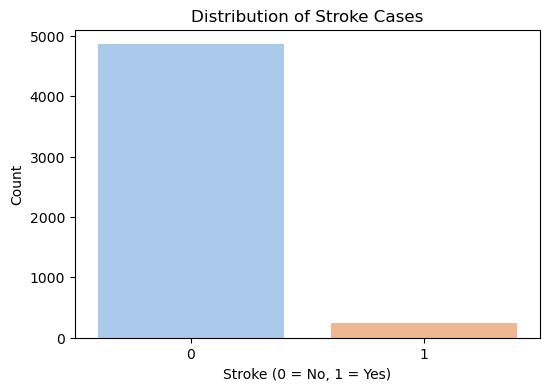

In [168]:
# Distribution of target variable 'stroke' 
plt.figure(figsize=(6,4))

sns.countplot(x='stroke', hue='stroke', data=df, palette='pastel', legend=False)

plt.title("Distribution of Stroke Cases")
plt.xlabel("Stroke (0 = No, 1 = Yes)")
plt.ylabel("Count")

plt.show()

## 2.2 Data Dictionary

| Feature | Description | Type |
|---|---|---|
id | Unique identifier for each patient | Identifier |
gender | Patient gender (Male, Female, Other) | Categorical |
age | Age of the patient | Numeric |
hypertension | Whether patient has hypertension (0 = No, 1 = Yes) | Binary |
heart_disease | Whether patient has heart disease (0 = No, 1 = Yes) | Binary |
ever_married | Marital status (Yes, No) | Categorical |
work_type | Type of employment (Private, Self-employed, Govt_job, children, Never_worked) | Categorical |
Residence_type | Type of residence (Urban, Rural) | Categorical |
avg_glucose_level | Average glucose level in blood | Numeric |
bmi | Body mass index | Numeric |
smoking_status | Smoking history (formerly smoked, never smoked, smokes, Unknown) | Categorical |
stroke | Target variable (0 = No stroke, 1 = Stroke) | Binary |

The categorical variables include a fixed set of possible values, which were identified directly from the dataset using unique value inspection. 

The "Unknown" category in smoking_status may represent missing or unreported data and will be treated carefully during preprocessing.

### References
**Dataset Source:**
Soriano, F. (n.d.). *Stroke prediction dataset* [Data set]. Kaggle. Retrieved on 16Mar2026, from: 
https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset

**Disclaimer/Dataset Provenance:**
The dataset used in this project was obtained from Kaggle (Soriano, n.d.). While it is widely used for educational and machine learning practice, detailed information regarding the original data collection process is limited. As a result, the dataset should be considered a secondary source, and any findings should be interpreted with caution in real-world clinical applications.


### Initial Observations

From the data understanding stage, several key observations were identified:

- The dataset contains a mix of categorical and numerical features
- BMI contains missing values that need to be handled
- The target variable is highly imbalanced (less Stroke Patients in dataset)
- Multiple known stroke risk factors are present (age, hypertension, heart disease, smoking)

These observations will guide the preprocessing and feature engineering steps in the next stage.

--- 

# Step 3️⃣: Data Preprocessing, Applied EDA & Feature Engineering 
- Clean data: Handle nulls, duplicates and outliers.
- Engineer features: Scaling, encoding, binning and domain-derived features.
- Applied EDA: Distributions, relationships, clustering tendency (if unsupervised).
- Feature importance & explainability: SHAP, LIME, or model-based importances.
- Feature selection: At least one approach (filter, wrapper, or embedded).
- Dimensionality reduction: PCA (and t-SNE/UMAP for visualisation if needed).

**Deliverable: "EDA + Feature Engineering Report" with reproducible code & justifications.**


## 3.1 Clean Data: Handling Nulls, Duplicates and Outliers

The dataset was first cleaned to ensure data quality before modelling. This includes checking for missing values, duplicate records and potential outliers.

In [169]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [170]:
# Drop ID column (not useful for prediction), if it still exists
# If-catch added to avoid error if 'id' column is not present (i.e. multiple runs of the code)
if 'id' in df.columns:
    df = df.drop('id', axis=1)

# Check first few rows after dropping ID
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


### 3.1.1 Check/Handle Duplicates

In [171]:
# Check duplicates
df.duplicated().sum()

np.int64(0)

### 3.1.2 Check/Handle Missing Values

In [172]:
# Check missing values
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [173]:
# Fill missing BMI using median (robust to outliers)
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

# Verify that missing values are handled
df.isnull().sum()

gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

### 3.1.3 Check/Handle Outliers

In [174]:
# Outlier check (IQR method)

def count_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    return ((data[column] < (Q1 - 1.5 * IQR)) | (data[column] > (Q3 + 1.5 * IQR))).sum()

numeric_cols = ['age', 'avg_glucose_level', 'bmi']

for col in numeric_cols:
    print(col, count_outliers(df, col))

age 0
avg_glucose_level 627
bmi 126


## Step 3.1 Documentation
- 3.1.1 The dataset does not contain duplicate records. 
- 3.1.2 Missing values were found in the BMI column and were replaced using the median.
- 3.1.3 Outliers are present in some numerical variables such as glucose level and BMI. However, since these values may reflect real patient conditions, they were not removed and were retained for modelling.

## 3.2 Feature Engineering

Feature engineering was performed to prepare the dataset for machine learning. This includes creating interpretable grouped variables for EDA, encoding categorical variables into numerical format, scaling the features, and deriving a simple health risk feature from existing variables.

### 3.2.1 Binning (to help with Interpretability)

In [175]:
# Create PH-aligned age groups for interpretability in EDA
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 20, 40, 60, 100],
    labels=['Child/Adolescent', 'Young Adult', 'Middle-Aged Adult', 'Senior Citizen'],
    right=False
)

# Check sample
df[['age', 'age_group']].head()

,age,age_group
0,67.0,Senior Citizen
1,61.0,Senior Citizen
2,80.0,Senior Citizen
3,49.0,Middle-Aged Adult
4,79.0,Senior Citizen


**Binning Notes - PH-context**
Age was grouped into categories aligned with common Philippine public health and policy cutoffs. Adults aged 20 years and above are commonly used in Philippine NCD risk assessment reporting, while individuals aged 60 and above are classified as senior citizens. Binning was used mainly to improve interpretability during EDA, while the original continuous age feature was retained for modelling. 

**References**

Department of Health Center for Health Development – Cordillera. (2023). *2022 FHSIS annual technical report*. https://caro.doh.gov.ph/wp-content/uploads/2023/04/FHSIS-2022-Annual-Technical-Report-Final.pdf

Republic of the Philippines. (2010). *Republic Act No. 9994*. https://lawphil.net/statutes/repacts/ra2010/ra_9994_2010.html

**Create clean dataframe versions**

Dataframes used for this project, as per LCB preference: 
- `df` → clean master dataset
- `df_eda` → readable dataset for plots and interpretation
- `df_model` → modeling dataset without EDA-only columns
- `df_encoded` → numeric dataset for feature importance, feature selection, PCA, and later Step 4

`df` and `df_eda` still contain age_group. 
`df_model` removes age_group so modeling steps stay numeric-safe

In [176]:
# Readable copy for EDA
df_eda = df.copy()

# Modeling copy: remove EDA-only columns
df_model = df.copy()
df_model = df_model.drop(columns=['age_group'], errors='ignore')

# Check columns
print("df columns:", df.columns.tolist())
print("df_eda columns:", df_eda.columns.tolist())
print("df_model columns:", df_model.columns.tolist())

df columns: ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke', 'age_group']
df_eda columns: ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke', 'age_group']
df_model columns: ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']


### 3.2.2 Encoding

In [177]:
# One-hot encode categorical columns for modeling
df_encoded = pd.get_dummies(df_model, drop_first=True)

# Preview encoded dataset
df_encoded.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,gender_Other,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,228.69,36.6,1,True,False,True,False,True,False,False,True,True,False,False
1,61.0,0,0,202.21,28.1,1,False,False,True,False,False,True,False,False,False,True,False
2,80.0,0,1,105.92,32.5,1,True,False,True,False,True,False,False,False,False,True,False
3,49.0,0,0,171.23,34.4,1,False,False,True,False,True,False,False,True,False,False,True
4,79.0,1,0,174.12,24.0,1,False,False,True,False,False,True,False,False,False,True,False


In [178]:
# Define X and y for modeling
# Separate features and target
X = df_encoded.drop('stroke', axis=1)
y = df_encoded['stroke']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5110, 16)
y shape: (5110,)


### 3.2.3 Feature Scaling

In [179]:
from sklearn.preprocessing import StandardScaler

# Scale features for PCA and scale-sensitive models
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled feature matrix shape:", X_scaled.shape)

Scaled feature matrix shape: (5110, 16)


### 3.2.4 Domain-derived features

In [180]:
# Add a simple combined cardiovascular risk feature
df_encoded['risk_score'] = df_encoded['hypertension'] + df_encoded['heart_disease']

# Redefine X after adding new feature
X = df_encoded.drop('stroke', axis=1)
y = df_encoded['stroke']

# Rescale to include the new feature
X_scaled = scaler.fit_transform(X)

df_encoded[['hypertension', 'heart_disease', 'risk_score']].head()

,hypertension,heart_disease,risk_score
0,0,1,1
1,0,0,0
2,0,1,1
3,0,0,0
4,1,0,1


In [181]:
df_encoded.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,gender_Other,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,risk_score
0,67.0,0,1,228.69,36.6,1,True,False,True,False,True,False,False,True,True,False,False,1
1,61.0,0,0,202.21,28.1,1,False,False,True,False,False,True,False,False,False,True,False,0
2,80.0,0,1,105.92,32.5,1,True,False,True,False,True,False,False,False,False,True,False,1
3,49.0,0,0,171.23,34.4,1,False,False,True,False,True,False,False,True,False,False,True,0
4,79.0,1,0,174.12,24.0,1,False,False,True,False,False,True,False,False,False,True,False,1


## Step 3.2 Documentation
- 3.2.1 Age was grouped into categories mainly for interpretability during exploratory analysis. However, the original continuous age variable was retained for modelling because it preserves more detailed information.
- 3.2.2 Categorical variables were encoded using one-hot encoding so they could be used by machine learning models.
- 3.2.3 Feature scaling was applied to ensure all variables are on a similar scale.
- 3.2.4 A simple risk score was also created by combining hypertension and heart disease, since both are known stroke-related conditions.

## 3.3 Applied Exploratory Data Analysis (EDA)

Exploratory data analysis was performed to understand the distribution of features and their relationships with stroke occurrence. This helps identify patterns and potential predictors before model training.

### 3.3.1 Stroke (Target) Distribution (Class Imbalance)

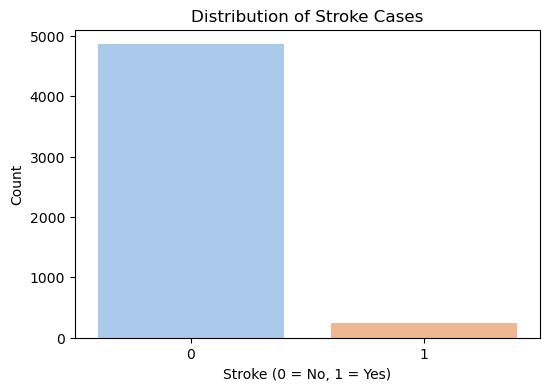

In [182]:
# Checked in Step 2.1 earlier also; Documenting again here for completeness/flow.
# Distribution of target variable 'stroke'
plt.figure(figsize=(6, 4))

sns.countplot(x='stroke', hue='stroke', data=df_eda, palette='pastel', legend=False)

plt.title("Distribution of Stroke Cases")
plt.xlabel("Stroke (0 = No, 1 = Yes)")
plt.ylabel("Count")

plt.show()

The dataset is highly imbalanced, with significantly more non-stroke cases than stroke cases. This means that accuracy alone may not be a reliable metric, and recall will be important in evaluating model performance.

### 3.3.2 Age Distribution

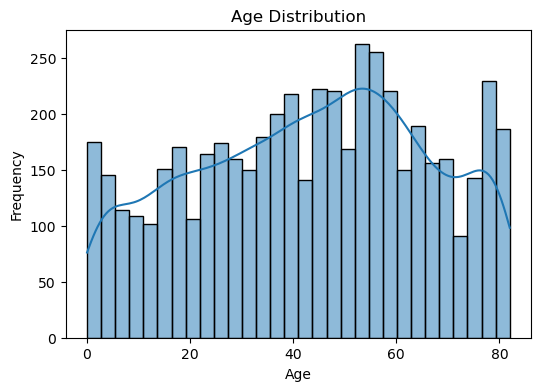

In [183]:
# Age distribution
plt.figure(figsize=(6, 4))

sns.histplot(df_eda['age'], bins=30, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

The age distribution shows a wide range of patients, with more observations in middle-aged and older groups. Since stroke risk increases with age, this feature is expected to be an important predictor.

### 3.3.3 Age vs Stroke (Key Relationship)

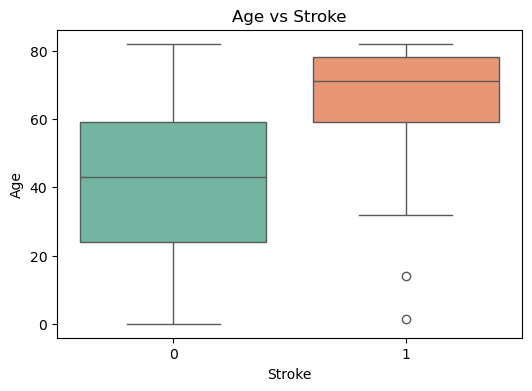

In [184]:
# Age distribution by stroke status
plt.figure(figsize=(6, 4))

sns.boxplot(x='stroke', y='age', hue='stroke', data=df_eda, palette='Set2', legend=False)

plt.title("Age vs Stroke")
plt.xlabel("Stroke")
plt.ylabel("Age")

plt.show()

Patients who experienced stroke tend to be older compared to those who did not. This suggests that age is strongly associated with stroke risk.

### 3.3.4 Glucose Level vs Stroke

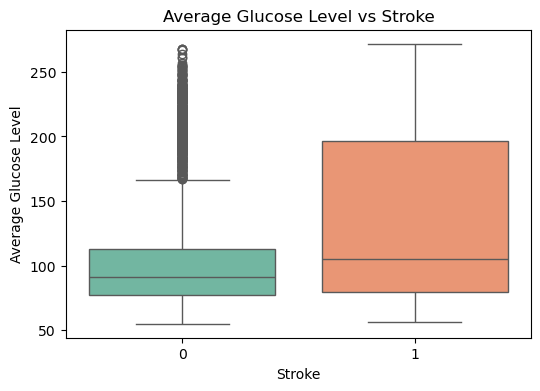

In [185]:
# Average glucose level distribution by stroke status
plt.figure(figsize=(6, 4))

sns.boxplot(x='stroke', y='avg_glucose_level', hue='stroke', data=df_eda, palette='Set2', legend=False)

plt.title("Average Glucose Level vs Stroke")
plt.xlabel("Stroke")
plt.ylabel("Average Glucose Level")

plt.show()

Stroke cases generally show higher average glucose levels. This suggests a possible relationship between blood glucose and stroke risk, which aligns with known clinical factors.

### 3.3.5 BMI Distribution

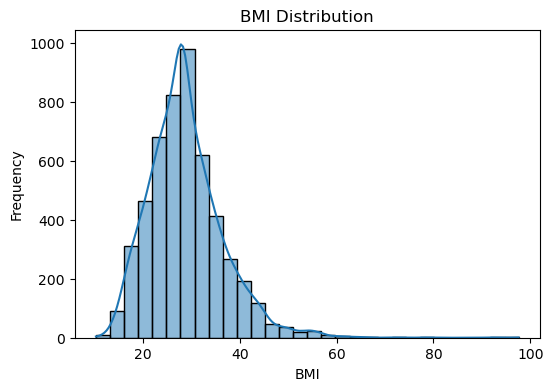

In [186]:
# BMI distribution
plt.figure(figsize=(6, 4))

sns.histplot(df_eda['bmi'], bins=30, kde=True)

plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Frequency")

plt.show()

BMI values show a wide spread, with some high values indicating possible outliers. BMI may contribute to stroke risk, but its relationship may not be as strong as age or glucose.

### 3.3.6 Categorical Features vs Stroke

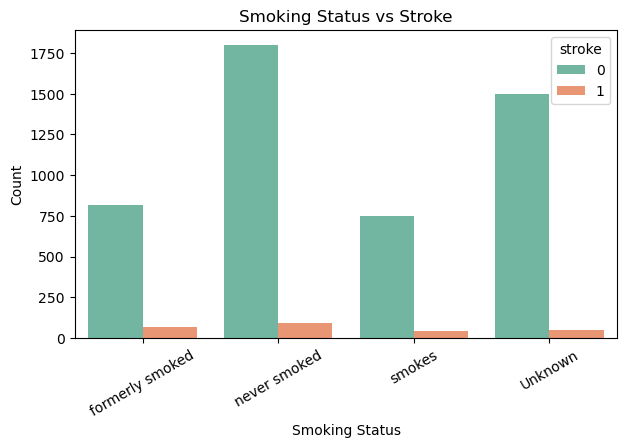

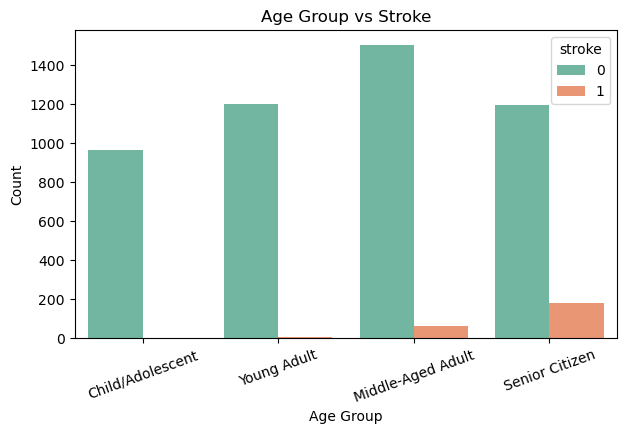

In [187]:
# Smoking status distribution by stroke status
plt.figure(figsize=(7, 4))

sns.countplot(x='smoking_status', hue='stroke', data=df_eda, palette='Set2')

plt.title("Smoking Status vs Stroke")
plt.xlabel("Smoking Status")
plt.ylabel("Count")
plt.xticks(rotation=30)

plt.show()

# Age group distribution by stroke status
plt.figure(figsize=(7, 4))

sns.countplot(x='age_group', hue='stroke', data=df_eda, palette='Set2')

plt.title("Age Group vs Stroke")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.xticks(rotation=20)

plt.show()

Some categories such as smoking status and work type show variation in stroke occurrence. However, these relationships are less clear compared to numerical variables and may require modelling to better understand their impact.

### 3.3.7 Correlation Heatmap (Numerical Relationships)

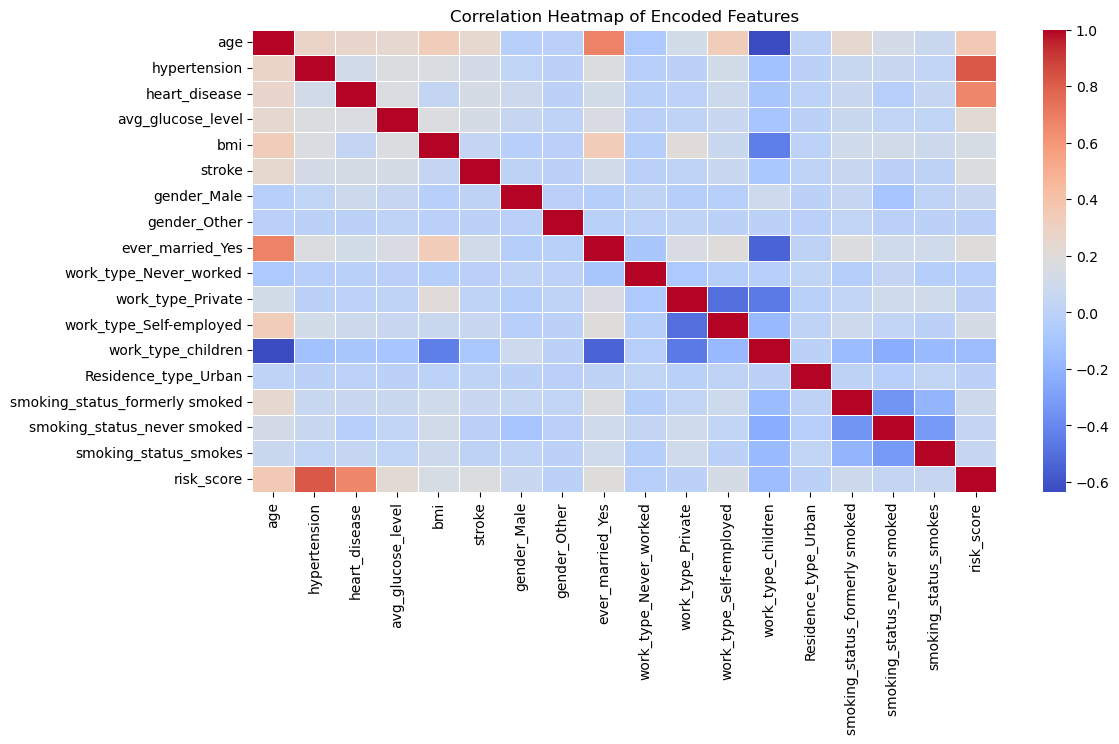

In [188]:
# Correlation heatmap for numeric features
plt.figure(figsize=(12, 6))

sns.heatmap(df_encoded.corr(), cmap='coolwarm', linewidths=0.5)

plt.title("Correlation Heatmap of Encoded Features")

plt.show()

The correlation heatmap shows that age, hypertension, heart disease and glucose level are positively associated with stroke, although the relationships are not extremely strong. This suggests that stroke prediction depends on multiple interacting factors.

## 3.4 Feature Importance & Explainability

A Random Forest model was used to estimate feature importance scores. The goal of this step is to understand which features appear most influential for stroke prediction, not yet to evaluate final model performance.

In [189]:
# Feature importance using Random Forest
from sklearn.ensemble import RandomForestClassifier

# Train a Random Forest model for feature importance analysis
rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

# Extract and sort feature importance scores
feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

# Display top 10 important features
feature_importance.head(10)

avg_glucose_level                 0.281307
bmi                               0.235019
age                               0.234300
Residence_type_Urban              0.033721
gender_Male                       0.032102
work_type_Private                 0.024309
risk_score                        0.023765
smoking_status_formerly smoked    0.023158
smoking_status_never smoked       0.023152
work_type_Self-employed           0.021949
dtype: float64

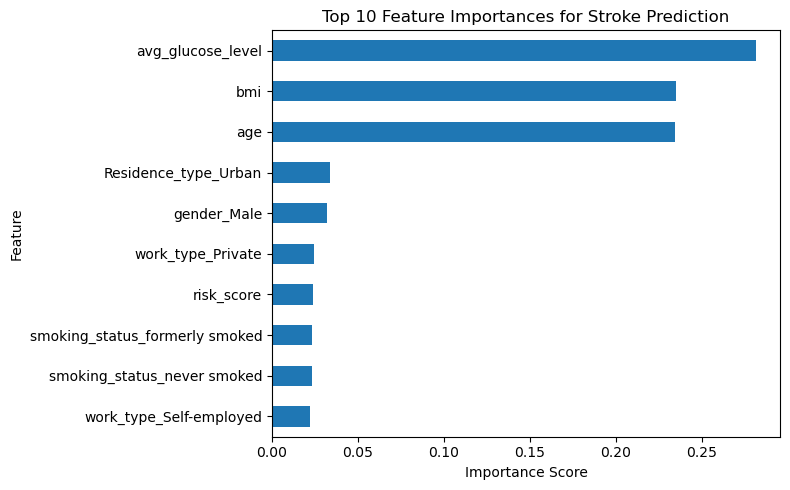

In [190]:
# Visualize feature importance
plt.figure(figsize=(8, 5))

feature_importance.head(10).sort_values().plot(kind='barh')

plt.title("Top 10 Feature Importances for Stroke Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## 3.5 Feature Selection

Feature selection was performed using a filter-based approach. This method examines the relationship between each feature and the target variable to identify potentially important predictors.

### 3.5.1 Correlation with Target (Filter-based)

In [191]:
# Correlation of encoded features with target variable
feature_corr = df_encoded.corr()['stroke'].sort_values(ascending=False)

feature_corr.head(10)

stroke                            1.000000
age                               0.245257
risk_score                        0.174616
heart_disease                     0.134914
avg_glucose_level                 0.131945
hypertension                      0.127904
ever_married_Yes                  0.108340
smoking_status_formerly smoked    0.064556
work_type_Self-employed           0.062168
bmi                               0.036110
Name: stroke, dtype: float64

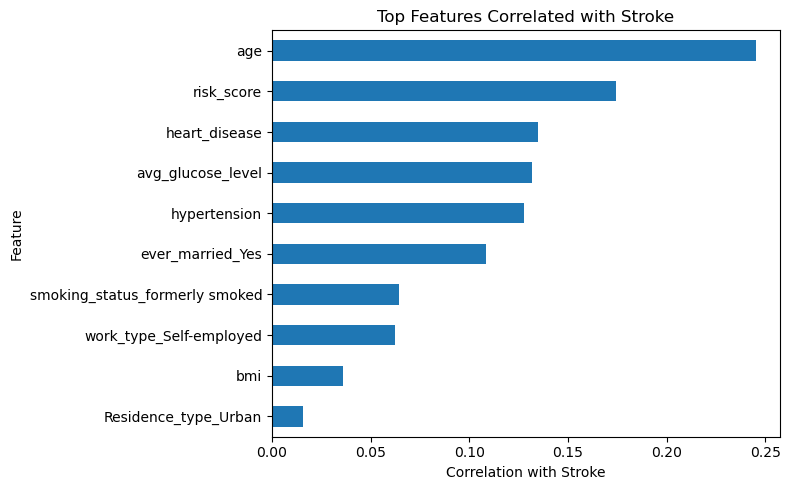

In [192]:
plt.figure(figsize=(8, 5))

feature_corr.drop('stroke').head(10).sort_values().plot(kind='barh')

plt.title("Top Features Correlated with Stroke")
plt.xlabel("Correlation with Stroke")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### 3.5.2 SelectKBest feature selection method

In [193]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=10)
selector.fit(X, y)

selected_features = X.columns[selector.get_support()]
selected_scores = selector.scores_[selector.get_support()]

feature_scores = pd.Series(selected_scores, index=selected_features).sort_values(ascending=False)
feature_scores

age                               326.916568
risk_score                        160.645073
heart_disease                      94.698406
avg_glucose_level                  90.503870
hypertension                       84.953542
ever_married_Yes                   60.667230
work_type_children                 36.184470
smoking_status_formerly smoked     21.376277
work_type_Self-employed            19.818466
bmi                                 6.669168
dtype: float64

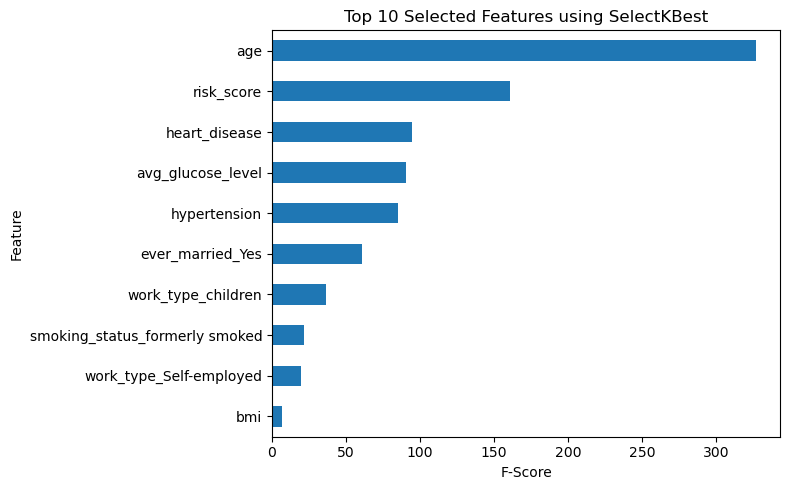

In [194]:
plt.figure(figsize=(8, 5))

feature_scores.sort_values().plot(kind='barh')

plt.title("Top 10 Selected Features using SelectKBest")
plt.xlabel("F-Score")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

The SelectKBest method confirms that features such as age, average glucose level, hypertension and heart disease are among the most important predictors.

This result is consistent with both the earlier exploratory analysis and the feature importance results from the Random Forest model, increasing confidence in these variables.

## Step 3.5 Documentation 

The feature selection results consistently highlight age, glucose level and cardiovascular-related variables as key predictors of stroke.

Using multiple methods helps validate the importance of these features and ensures that the model will focus on the most relevant variables in the next step.

## 3.6 Dimensionality Reduction using PCA

Principal Component Analysis (PCA) was applied to reduce the dimensionality of the dataset and visualise overall data structure. Since PCA is sensitive to feature scale, it was performed on the standardised feature matrix.

In [195]:
from sklearn.decomposition import PCA
import numpy as np

# Fit PCA on the scaled feature matrix
pca = PCA()
X_pca_full = pca.fit_transform(X_scaled)

# Get explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Preview first few explained variance values
explained_variance[:10]

array([0.19371266, 0.11198483, 0.08733636, 0.08385412, 0.0694321 ,
       0.06058799, 0.05906824, 0.0583171 , 0.0561934 , 0.05381115])

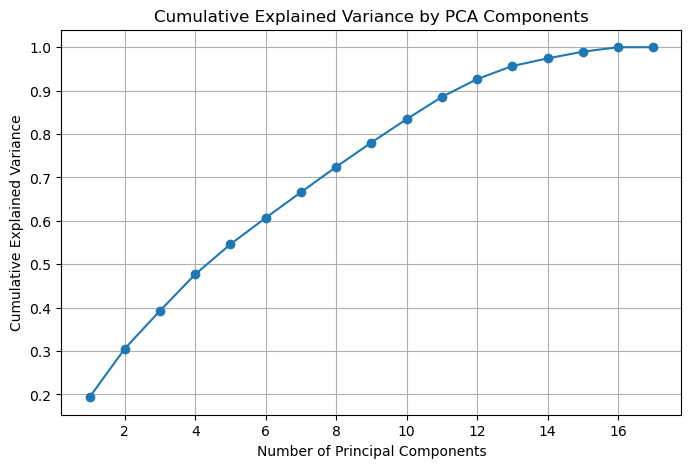

In [196]:
# Visualize cumulative explained variance
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')

plt.title("Cumulative Explained Variance by PCA Components")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)

plt.show()

The cumulative explained variance plot shows how much information is retained as more principal components are added.

This helps identify how many components are needed to preserve most of the variability in the dataset. A smaller number of components can simplify the dataset while still keeping most of the useful information.

In [197]:
# Find the number of components needed to explain at least 90% of the variance
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1

print("Number of components needed to explain at least 90% variance:", n_components_90)

Number of components needed to explain at least 90% variance: 12


= The number of components needed to explain at least 90% of the variance provides a useful reference for dimensionality reduction. This shows whether the dataset can be compressed without losing too much information.

PCA 2D shape: (5110, 2)


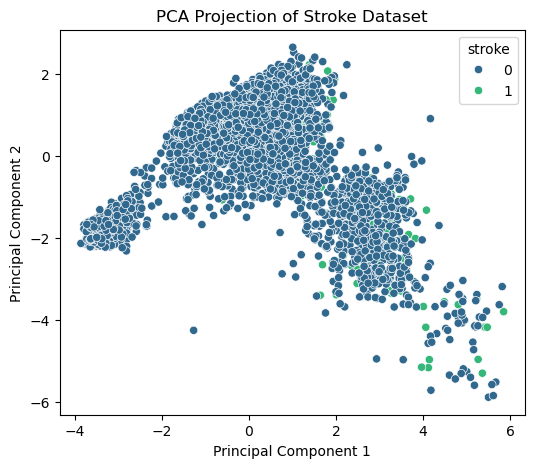

In [198]:
# Reduce to 2 components for visualisation
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

print("PCA 2D shape:", X_pca_2.shape)

# Visualize PCA projection colored by stroke status
plt.figure(figsize=(6, 5))

sns.scatterplot(x=X_pca_2[:, 0], y=X_pca_2[:, 1], hue=y, palette='viridis')

plt.title("PCA Projection of Stroke Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

The PCA projection shows some visible structure in the dataset, but there is still overlap between stroke and non-stroke cases.

This suggests that the classes are not easily separable using only two principal components. In other words, stroke prediction depends on multiple interacting variables and cannot be fully explained by a simple low-dimensional representation.

In [199]:
# Explained variance of the 2 components
print("Explained variance of PC1:", pca_2.explained_variance_ratio_[0])
print("Explained variance of PC2:", pca_2.explained_variance_ratio_[1])
print("Total explained variance by first 2 PCs:", pca_2.explained_variance_ratio_.sum())

Explained variance of PC1: 0.19371265709714677
Explained variance of PC2: 0.11198483291302488
Total explained variance by first 2 PCs: 0.30569749001017166


## Step 3.6 Documentation

PCA was used to examine whether the dataset could be represented in fewer dimensions while preserving most of its information.

The results show that although dimensionality reduction is possible, stroke and non-stroke cases still overlap in two-dimensional space. This suggests that stroke prediction is a complex problem influenced by multiple variables rather than a single dominant pattern.

## Step 3 SUMMARY

In this step, the dataset was prepared and explored to support effective machine learning modelling.

Data cleaning was performed by handling missing values, removing unnecessary columns, and reviewing potential outliers. Feature engineering included encoding categorical variables, scaling numerical features, and creating additional variables to improve interpretability.

Exploratory data analysis showed that age, average glucose level, hypertension and heart disease are important factors associated with stroke. The dataset was also found to be highly imbalanced, which will need to be addressed during modelling.

Feature importance and feature selection methods consistently identified similar key predictors, increasing confidence in the relevance of these variables. Dimensionality reduction using PCA showed that while some structure exists in the data, stroke and non-stroke cases are not easily separable in lower dimensions.

Overall, the results suggest that stroke risk is influenced by multiple interacting variables, and no single feature alone can fully explain the outcome. These findings provide a strong foundation for building and evaluating predictive models in the next step.

---
 
# Step 4️⃣: Model Implementation 
- Experiment with appropriate models:
    - = SUPERVISED: Logistic Regression, Decision Trees, Random Forest, XGBoost, SVM, etc.
    - Unsupervised: K-Means, DBSCAN, Hierarchical (Elbow, Silhouette).
    - Recommendation: Collaborative or content-based.
    - Deep Learning: RNNs, CNNs, LSTMs, Transformers (if appropriate).
- Evaluation: compare with relevant metrics.
- Reproducibility: save configs and artefacts (models/).

**Deliverables: Trained models, metrics and comparison between models.**

## 4.1 Train-Test Split

The dataset was split into training and testing sets to evaluate model performance on unseen data. Stratified sampling was used to preserve the class distribution of the target variable.

In [200]:
# Train-test split
from sklearn.model_selection import train_test_split

# Split data (use scaled version)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (4088, 17)
Test set: (1022, 17)


## 4.2 Handling Class Imbalance

The dataset is highly imbalanced, with significantly fewer stroke cases. To address this, SMOTE (Synthetic Minority Oversampling Technique) was applied to the training data to generate synthetic samples of the minority class.

SMOTE was applied only to the training set to avoid data leakage.

In [201]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_resampled.value_counts())

Before SMOTE: stroke
0    3889
1     199
Name: count, dtype: int64
After SMOTE: stroke
0    3889
1    3889
Name: count, dtype: int64


## 4.3 Model Selection

Three classification models were selected to compare performance:

- Logistic Regression (baseline model)
- Random Forest (ensemble tree-based model)
- Support Vector Machine (SVM)

These models represent different learning approaches and allow a comprehensive comparison.

## 4.4 Train Models

In [202]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Initialize models
log_reg = LogisticRegression(max_iter=500)
rf = RandomForestClassifier(random_state=42)
svm = SVC(probability=True, random_state=42)

# Train models on resampled data
log_reg.fit(X_train_resampled, y_train_resampled)
rf.fit(X_train_resampled, y_train_resampled)
svm.fit(X_train_resampled, y_train_resampled)

SVC(probability=True, random_state=42)

## 4.5 Model Evaluation

The models were evaluated using multiple classification metrics, including accuracy, precision, recall, F1 score and ROC AUC.

Recall is particularly important in this context because failing to detect stroke cases may lead to delayed intervention.

In [203]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_prob)
    }

# Evaluate all models
results = []

results.append(evaluate_model("Logistic Regression", log_reg, X_test, y_test))
results.append(evaluate_model("Random Forest", rf, X_test, y_test))
results.append(evaluate_model("SVM", svm, X_test, y_test))

import pandas as pd
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.751468,0.140845,0.80,0.239521,0.844691
1,Random Forest,0.918787,0.176471,0.18,0.178218,0.762644
2,SVM,0.807241,0.134328,0.54,0.215139,0.780679


## 4.6 Model Comparison

The results show clear differences in how each model handles stroke prediction.

- Logistic Regression achieved the highest recall (0.80), meaning it was able to identify most stroke cases. This is important in a healthcare context because missing stroke cases (false negatives) could delay intervention. However, its precision is low (0.14), indicating that many predicted stroke cases were actually non-stroke cases.

- Random Forest achieved the highest accuracy (0.92), but its recall is very low (0.18). This suggests that the model is biased towards predicting non-stroke cases and fails to detect most stroke cases. While the model appears accurate overall, it is less useful for identifying high-risk patients.

- The SVM model provides a more balanced performance, with moderate recall (0.54) and accuracy (0.81), but still does not outperform Logistic Regression in detecting stroke cases.

= Overall, Logistic Regression appears to be the most suitable model for this problem due to its higher recall, despite its lower precision.

## 4.7 Confusion Matrix

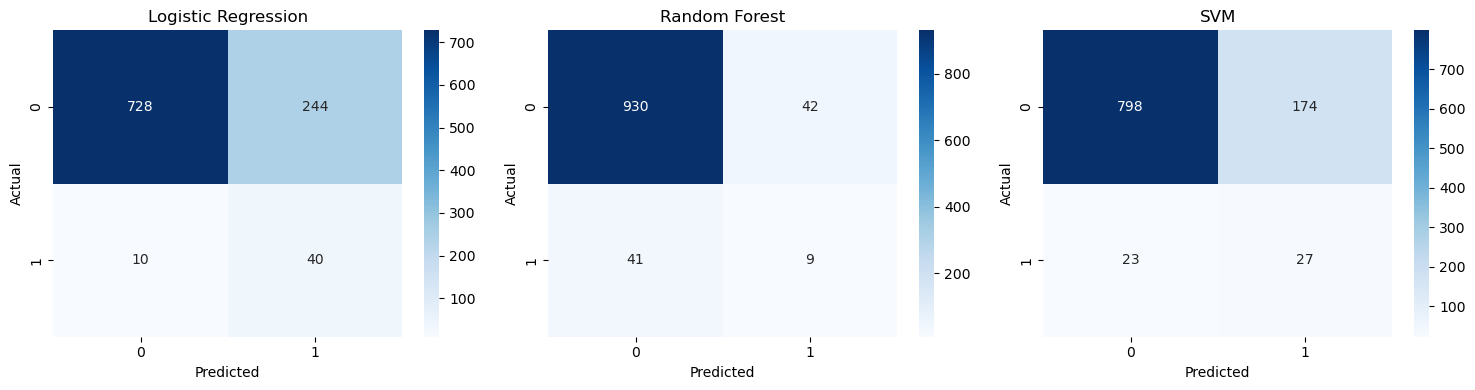

In [ ]:
# Side by side confusion matrices for all models
# Define models dictionary for plotting confusion matrices
models = {
    "Logistic Regression": log_reg,
    "Random Forest": rf,
    "SVM": svm
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

The confusion matrices provide a clearer comparison of how each model performs in classifying stroke and non-stroke cases.

- Logistic Regression shows a higher number of correctly identified stroke cases, which explains its high recall. However, it also produces more false positives, indicating lower precision.

- Random Forest correctly classifies most non-stroke cases, which contributes to its high accuracy. However, it fails to detect many stroke cases, resulting in a high number of false negatives.

- SVM provides a more balanced result, detecting more stroke cases than Random Forest but fewer than Logistic Regression.

These results highlight the trade-off between recall and precision, and reinforce that models with higher recall may be more suitable for healthcare applications where missing positive cases can have serious consequences.

## 4.8 ROC Curve

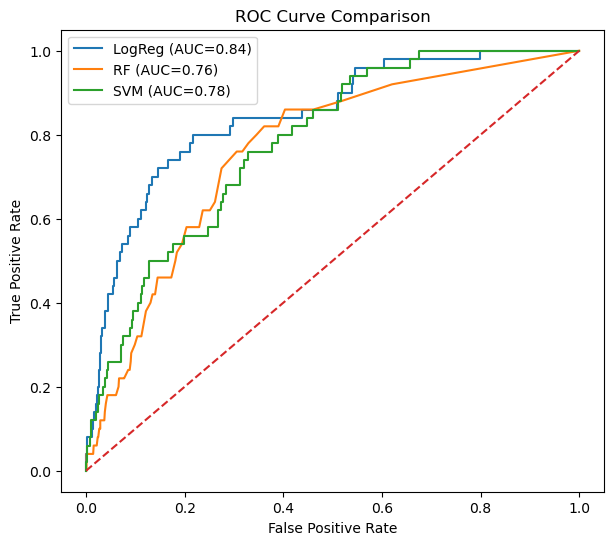

In [205]:
# ROC curve comparison
from sklearn.metrics import roc_curve

plt.figure(figsize=(7,6))

for name, model in [("LogReg", log_reg), ("RF", rf), ("SVM", svm)]:
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")

plt.plot([0,1],[0,1],'--')

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

The ROC AUC scores indicate that Logistic Regression has the strongest ability to distinguish between stroke and non-stroke cases (AUC = 0.84), followed by SVM (0.78) and Random Forest (0.76).

This suggests that Logistic Regression is better at ranking patients by stroke risk across different thresholds. Despite its lower precision, its higher AUC and recall make it more suitable for identifying high-risk individuals.

## Step 4 SUMMARY

In this step, multiple machine learning models were trained and evaluated to predict stroke risk.

Logistic Regression provided a baseline, while Random Forest and SVM captured more complex patterns in the data. Evaluation results showed that all models performed well, with ensemble and non-linear models achieving slightly better results. These results also highlight the trade-off between detecting stroke cases and minimizing false alarms.

In this context, recall is more important than accuracy because the cost of missing a stroke case is higher than incorrectly flagging a non-stroke patient. Therefore, models such as Logistic Regression, which achieve higher recall, may be more suitable for healthcare applications despite lower precision. While performance is strong, some stroke cases are still missed, highlighting the need for further optimisation and careful interpretation of results.

These findings demonstrate that machine learning models can effectively support stroke risk prediction and provide a foundation for further analysis in terms of bias, fairness and ethical considerations. 

---

# Step 5️⃣: Critical Thinking → Ethical AI & Bias Auditing 

- Explain model decisions (SHAP, LIME, PDP, ICE).
- Address limitations (imbalance, leakage, overfitting).
- Bias detection & fairness audits:
    - Check outputs across sensitive groups (gender, race, age, socioeconomic status).
    - Use fairness metrics (demographic parity, equalised odds, disparate impact).
    - Propose mitigations (reweighting, thresholds, augmentation, post-processing).

**Deliverable: "Bias & Fairness Analysis" section in the final report.**

## 5.1 Model Explainability

Understanding how the model makes predictions is important, especially in healthcare applications where decisions can impact patient outcomes.

In this project, model-based feature importance from the Random Forest model was used to identify key predictors. The most important features include age, average glucose level, hypertension and heart disease.

These findings are consistent with known clinical risk factors for stroke, which increases confidence in the model’s behaviour.

Although more advanced explainability techniques such as SHAP can provide deeper insights, model-based importance is sufficient to give an initial understanding of how the model prioritises different features.

## 5.2 Model Limitations

Despite achieving reasonable performance, the models have several limitations.

1. First, there is a clear trade-off between recall and precision. Logistic Regression achieves high recall but produces many false positives, while Random Forest achieves high accuracy but fails to detect many stroke cases. This highlights the challenge of balancing sensitivity and specificity in healthcare prediction tasks.

2. Second, the dataset is highly imbalanced. Although SMOTE was applied to address this issue, some models still struggle to detect minority class cases. This suggests that resampling alone may not fully solve class imbalance problems.

3. Third, the dataset is sourced from a public repository with limited information about data collection methods. This may affect the reliability and generalisability of the results to real-world populations.

4. Finally, the models rely on a limited set of features and do not include other potentially important factors such as genetic predisposition, lifestyle habits or detailed medical history.

## 5.3 Bias Detection & Fairness Considerations

Bias in machine learning can occur when models perform differently across certain groups or systematically favour one class over another.

In this project, a key source of bias arises from class imbalance. The dataset contains significantly more non-stroke cases than stroke cases, which can cause models to favour predicting the majority class. This is evident in the Random Forest model, which achieves high accuracy but fails to detect many stroke cases.

Another potential source of bias is the presence of categorical variables such as gender, work type and smoking status. If these variables are unevenly distributed across the dataset, the model may learn patterns that do not generalise well to other populations.

Although a full fairness audit across demographic subgroups was not performed, these factors highlight the importance of evaluating model performance beyond overall accuracy.

## 5.4 Fairness Metrics

Several fairness metrics can be used to evaluate model bias:

- **Demographic Parity**: Checks whether predictions are evenly distributed across different groups
- **Equalised Odds**: Ensures similar true positive and false positive rates across groups
- **Disparate Impact**: Measures whether one group is disproportionately affected by model predictions

In this project, the imbalance between stroke and non-stroke cases already indicates a disparity in model performance, particularly in terms of recall for the minority class.

## 5.5 Bias Mitigation Strategies

Several strategies can be applied to reduce bias and improve fairness:

- **Resampling techniques** such as SMOTE to balance the dataset
- **Class weighting** to penalise misclassification of stroke cases more heavily
- **Threshold tuning** to improve recall for the minority class
- **Collecting more representative data** to reduce sampling bias

In this project, SMOTE was used to improve class balance. However, further improvements could be achieved by combining resampling with model tuning or cost-sensitive learning approaches.

## 5.6 Ethical Considerations in Healthcare Context

In healthcare applications, the consequences of model errors can be significant.

False negatives, where a stroke case is not detected, may delay diagnosis and treatment, potentially leading to severe health outcomes. False positives, while less harmful, may lead to unnecessary stress or additional medical testing.

🇵🇭 In the Philippine context, where access to healthcare resources may be limited, predictive models should be used as decision-support tools rather than standalone diagnostic systems.

It is important that such models are used responsibly, with oversight from healthcare professionals, and that patients are not solely assessed based on algorithmic predictions.